# RAGWire in Practice — Providers and Cookbooks

Progressive journey:
- Swap providers with a single config change
- Use Qdrant Cloud with MMR retrieval

## 1. Setup

In [1]:
from dotenv import load_dotenv
load_dotenv()

from ragwire import RAGWire, setup_logging
import ragwire

logger = setup_logging(log_level="INFO")
print(ragwire.__version__)

1.2.9


## 2. RAGWire with All Providers

Switch providers by changing the config file. All agents share the same tools.

| Config | Embedding | LLM |
|---|---|---|
| `config_ollama.yaml` | `qwen3-embedding:0.6b` (Ollama) | `qwen3.5:27b` (Ollama) |
| `config_gemini.yaml` | `gemini-embedding-001` (Google) | `gemini-3.1-flash-lite-preview` (Google) |
| `config_openai.yaml` | `text-embedding-3-small` (OpenAI) | `gpt-5.4-nano` (OpenAI) |
| `config_groq.yaml` | `all-MiniLM-L6-v2` (HuggingFace) | `qwen/qwen3-32b` (Groq) |

In [ ]:
# rag = RAGWire('config_ollama.yaml')

# stats = rag.ingest_directory('../data/finance_data')

### OpenAI

In [ ]:
rag_openai = RAGWire('config_openai.yaml')

stats = rag_openai.ingest_directory('../data/finance_data')

In [ ]:
rag_openai.retrieve("what is apple revenue in 2025?")

### Groq

In [ ]:
#!pip install langchain-huggingface

In [ ]:
load_dotenv(override=True)

rag_groq = RAGWire('config_groq.yaml')

In [ ]:
import os
rag_groq.ingest_documents([os.path.abspath('../data/finance_data/amazon 10-k 2024.pdf')])
# rag_groq.ingest_documents([r'..\data\finance_data\amazon 10-k 2024.pdf'])

In [ ]:
rag_groq.retrieve("what is amazon revenue in 2024?")

### Gemini

In [ ]:
load_dotenv(override=True)

In [ ]:
# import os
# os.getenv('GOOGLE_API_KEY')

In [ ]:
rag_gemini = RAGWire('config_gemini.yaml')

In [ ]:
rag_gemini.ingest_documents([r'..\data\finance_data\amazon 10-k 2024.pdf'])

In [ ]:
rag_gemini.retrieve("what is amazon revenue in 2024?")

## 3. Cookbook — OpenRouter Tiers + Local Qdrant Retrieval

This is a separate OpenRouter path; the OpenAI, Gemini, Groq, and Ollama provider examples above remain unchanged. `config_openrouter_qdrant.yaml` matches Lesson 02's local `BAAI/bge-base-en-v1.5` embeddings and existing Qdrant collection, while selecting the chat model by tier.

- `MODEL_TIER = "free"` uses NVIDIA Nemotron. Free NVIDIA endpoints may log prompts, so use public, non-sensitive documents only.
- `MODEL_TIER = "paid"` uses Nex N2 Mini and requires OpenRouter credit; selecting it is an explicit billable choice.
- `vectorstore.url` points to local Qdrant at `http://localhost:6333`, started with `../start_qdrant.sh`. The existing collection is retained because the embedding model has not changed.

The agent reuses `rag_qdrant.llm`, so it cannot drift from the RAGWire-selected model.

In [6]:
load_dotenv(override=True)

CONFIG_PATH = "config_openrouter_qdrant.yaml"
MODEL_TIER = "paid"  # Change to "paid" only when you explicitly accept OpenRouter charges.

rag_qdrant = RAGWire(CONFIG_PATH, model_tier=MODEL_TIER)
print(f"Using {rag_qdrant.model_tier} model: {rag_qdrant.config['llm']['model']}")

2026-08-31 03:50:46,043 - ragwire.core.pipeline - INFO - Loading configuration from config_openrouter_qdrant.yaml
2026-08-31 03:50:46,047 - ragwire.core.pipeline - INFO - Selected paid LLM model: nex-agi/nex-n2-mini
2026-08-31 03:50:46,061 - ragwire.core.pipeline - INFO - Document loader initialized
2026-08-31 03:50:46,062 - ragwire.core.pipeline - INFO - Text splitter initialized (strategy=markdown, chunk_size=10000)
2026-08-31 03:50:46,223 - ragwire.core.pipeline - INFO - Embedding model initialized (provider=fastembed)
2026-08-31 03:50:46,227 - ragwire.core.pipeline - INFO - Metadata extractor loaded from: finance_metadata.yaml
2026-08-31 03:50:46,227 - ragwire.core.pipeline - INFO - LLM initialized for metadata extraction (provider=openrouter, model=nex-agi/nex-n2-mini)
2026-08-31 03:50:46,240 - ragwire.vectorstores.qdrant_store - INFO - Connected to Qdrant at http://localhost:6333 (timeout=300s)
2026-08-31 03:50:46,247 - ragwire.core.pipeline - INFO - Using existing collection: fi

In [7]:
rag_qdrant.ingest_directory("../data/finance_data")

2026-08-31 03:50:47,733 - ragwire.core.pipeline - INFO - Found 7 file(s) in ../data/finance_data
2026-08-31 03:50:47,733 - ragwire.core.pipeline - INFO - Starting ingestion of 7 documents


Ingesting:   0%|          | 0/7 [00:00<?, ?file/s]

2026-08-31 03:50:47,746 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/apple 10-k 2024.pdf
2026-08-31 03:50:47,757 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/amazon 10k 2025.pdf
2026-08-31 03:50:47,772 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/google 10-k 2024.pdf
2026-08-31 03:50:47,781 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Apple_10k_2025.pdf
2026-08-31 03:50:47,789 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/GOOG-10-K-2025.pdf
2026-08-31 03:50:47,800 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/Facebook-10k-2025.pdf
2026-08-31 03:50:47,807 - ragwire.core.pipeline - INFO - Skipping (already ingested): ../data/finance_data/amazon 10-k 2024.pdf


Ingesting: 100%|██████████| 7/7 [00:00<00:00, 95.96file/s]

2026-08-31 03:50:47,870 - ragwire.core.pipeline - INFO - Ingestion complete: 0/7 documents


{'total': 7,
 'processed': 0,
 'skipped': 7,
 'failed': 0,
 'chunks_created': 0,
 'errors': []}

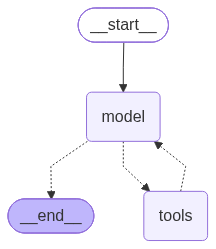

In [8]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from typing import Any
import json

@tool
def get_filter_context(query: str) -> str:
    """Get available metadata fields, stored values, and filter suggestions for a query.

    Call this before search_documents when the query involves a specific company,
    year, or document type. Skip for purely semantic queries.
    """
    return rag_qdrant.get_filter_context(query)

@tool
def search_documents(
    query: str, filters: dict[str, Any] | str | None = None
):
    """Search the document knowledge base for relevant information.

    Args:
        query: The search query
        filters: Optional metadata filters from get_filter_context. Pass a JSON object,
            for example {"company_name": "apple inc.", "fiscal_year": 2024}.
    """

    # Some providers serialize tool arguments as a JSON string. Convert that
    # form before passing filters to RAGWire, which requires a dictionary.
    if isinstance(filters, str):
        try:
            filters = json.loads(filters)
        except json.JSONDecodeError:
            return (
                "Invalid filters. Pass a JSON object, for example "
                '{"company_name": "apple inc.", "fiscal_year": 2024}.'
            )

    if filters is not None and not isinstance(filters, dict):
        return "Invalid filters. filters must be a JSON object or omitted."

    results = rag_qdrant.retrieve(query=query, filters=filters)

    if not results:
        return "No relevant information is found!"
    else:
        return results 
    
agent = create_agent(
    model=rag_qdrant.llm,
    tools=[get_filter_context, search_documents],
    system_prompt=(
        "You are a helpful financial document assistant. "
        "For complex questions, break them down into simple sub-questions. "
        "Always use search_documents to retrieve information — never answer from general knowledge. "
        "Use get_filter_context before search_documents when the query involves specific metadata. "
        "Always cite the source document in your answer."
    ),
    checkpointer=InMemorySaver(),
)

agent



In [9]:
config = {"configurable": {"thread_id": "demo"}}

print("\nRAG Agent ready. Type 'quit' to exit.\n")

while True:
    question = input("You: ").strip()
    if question.lower() in ("quit", "exit", "q"):
        break
    if not question:
        continue
    response = agent.invoke(
        {"messages": [HumanMessage(question)]},
        config=config,
    )
    print(f"\nAgent: {response['messages'][-1].text}\n")


RAG Agent ready. Type 'quit' to exit.

2026-08-31 03:51:10,110 - ragwire.core.pipeline - INFO - Auto-extracted filters from query: {'company_name': 'apple inc.'}
2026-08-31 03:51:11,106 - ragwire.core.pipeline - INFO - Retrieved 5 documents for query: What is Apple's total revenue?...

Agent: Apple’s total revenue, reported as **total net sales**, was **$416.161 billion** for fiscal year 2025.

Source: Apple Inc. 2025 Form 10-K, *Consolidated Statements of Operations* and *Note 2 – Revenue*, showing “Total net sales” of **$416,161 million** for the year ended September 27, 2025.

